In [2]:
using SimpleHypergraphs

In [26]:
using Makie
using GLMakie
using NetworkLayout
using Random
using Colors
using ColorSchemes
using Graphs
using GraphMakie

In [10]:
file_path = "data/publications.hif.json" # Your specified file path
# note that SimpleHypergraphs.jl uses 1-based numbering of vertices and hyperedges.
# Hence renumbering is required when outher ids are used in the input json
# We can however keep the original id in the vertex/edge metadata using the `add_original_id_to_meta` parameter
hg = hg_load(file_path; format=HIF_Format(), T=Bool, add_original_id_to_meta=:origid)

┌ Warning: Nodes in the source file were not sorted or not consistent - their order will change
└ @ SimpleHypergraphs /Users/Shared/AAABIBLIOTEKA/NCN2/SimpleHypergraphs.jl/src/io_hif.jl:95
┌ Warning: Edges in the source file were not sorted or not consistent - their order will change
└ @ SimpleHypergraphs /Users/Shared/AAABIBLIOTEKA/NCN2/SimpleHypergraphs.jl/src/io_hif.jl:99


1960×533 Hypergraph{Bool, Union{Nothing, Dict{Symbol, Any}}, Union{Nothing, Dict{Symbol, Any}}, Dict{Int64, Bool}}:
 1          nothing   nothing   nothing  …   nothing  nothing   nothing
  nothing  1          nothing   nothing      nothing  nothing   nothing
  nothing  1          nothing   nothing      nothing  nothing   nothing
  nothing  1          nothing   nothing      nothing  nothing   nothing
  nothing   nothing  1         1             nothing  nothing   nothing
  nothing   nothing  1         1         …   nothing  nothing   nothing
  nothing   nothing   nothing   nothing      nothing  nothing   nothing
  nothing   nothing   nothing   nothing      nothing  nothing   nothing
  nothing   nothing   nothing   nothing      nothing  nothing   nothing
  nothing   nothing   nothing   nothing      nothing  nothing   nothing
  nothing   nothing   nothing   nothing  …   nothing  nothing   nothing
  nothing   nothing   nothing   nothing      nothing  nothing   nothing
  nothing   nothing 

In [16]:
# it can be seen that the title was used as the hyperedge identifier. Similary, author name was used as the vertex identifier
hg.he_meta[end]

Dict{Symbol, Any} with 6 entries:
  :funding_agencies => Any[]
  :origid           => "Asymptotically sharp bounds for cancellative and union-…
  :abstract         => "An \$r\$-graph is called \$t\$-cancellative if for arbi…
  :date             => "2024-11-12"
  :tags             => Any["Combinatorics"]
  :source           => "Arxiv"

In [44]:
cmpts = get_connected_components(hg)
n, id = findmax(length, cmpts)
to_select = Set(cmpts[id])
for v in nhv(hg):-1:1
    if !(v in to_select)
        remove_vertex!(hg, v)
    end
end
SimpleHypergraphs.prune_hypergraph(hg)

cnm = CFModularityCNMLike(5000)
Random.seed!(1234)
cnm_comms = findcommunities(hg, cnm)

println("We found $(length(cnm_comms.bp)) communities ")

t = Graphs.Graph(get_twosection_adjacency_mx(hg;replace_weights=1))

my_colors = vcat(ColorSchemes.rainbow[range(1, stop=length(ColorSchemes.rainbow), step=3)], ColorSchemes.rainbow[2]);
function get_color(i, comms, colors)
    for j in 1:length(comms)
        if length(comms[j]) > 1 && i in comms[j]
            return "#"*hex(colors[j % length(colors) + 1])
        end
    end
    return "#000000"
end;

degrees = Graphs.degree.(Ref(t), Graphs.vertices(t));
dsize = 7 .+ 12 .* degrees./maximum(degrees);


We found 16 communities 


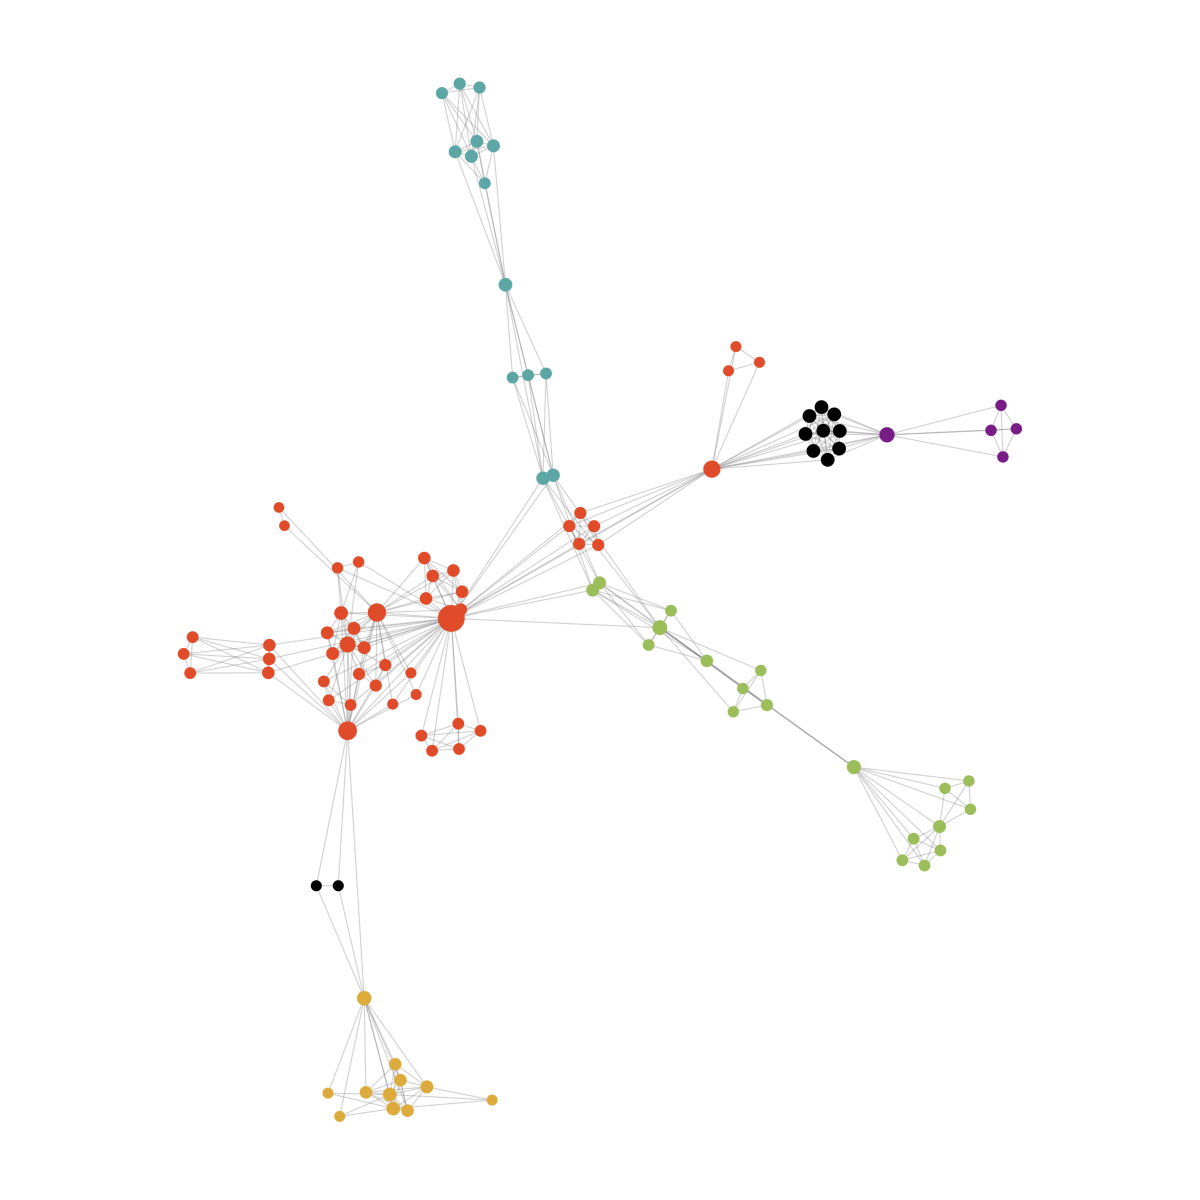

In [45]:
fig = Figure(size = (600, 600))
ax  = Axis(fig[1, 1]; aspect = DataAspect())
hidedecorations!(ax)
hidespines!(ax)
graphplot!(t;
    node_size  = dsize,
    node_color = get_color.(1:Graphs.nv(t), Ref(cnm_comms.bp), Ref(reverse(my_colors))),
    edge_width = 0.5,                 
    edge_color = RGBA(0.5, 0.5, 0.5, 0.4)  
)

fig


#### Akcnowledgments
Development of HIF-standard integration along with this tutorial was funded by the National
Science Centre (NCN), Poland (grant number: 2021/41/B/HS4/03349).